In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error,
                              mean_absolute_error, r2_score)
import lightgbm as lgb
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8')

meter_map = {0:'Electricity', 1:'Chilled Water',
             2:'Steam', 3:'Hot Water'}

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
df = pd.read_parquet(
    '/content/drive/MyDrive/hvac_project/eda_final_v3.parquet'
)

print(f"✅ Data loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

✅ Data loaded!
   Shape   : (4316560, 19)
   Columns : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'air_temperature', 'dew_temperature', 'sea_level_pressure', 'wind_speed', 'hour', 'month', 'weekday', 'is_weekend', 'meter_name', 'CDD', 'HDD', 'meter_reading_log']


In [ ]:
print("--- Verification ---")
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Negative vals  : {(df['meter_reading'] < 0).sum()}")

print(f"\nRows per meter:")
for meter_id, meter_name in meter_map.items():
    total = len(df[df['meter'] == meter_id])
    nonzero = len(df[(df['meter']==meter_id) &
                      (df['meter_reading']>0)])
    print(f"  {meter_name:15} : {total:,} total | {nonzero:,} non-zero")

--- Verification ---
Shape          : (4316560, 19)
Missing values : 3138
Negative vals  : 0

Rows per meter:
  Electricity     : 1,731,963 total | 1,678,997 non-zero
  Chilled Water   : 1,207,968 total | 1,051,414 non-zero
  Steam           : 865,568 total | 793,841 non-zero
  Hot Water       : 511,061 total | 435,804 non-zero


In [ ]:
def get_season(month):
    if month in [12, 1, 2]: return 0
    elif month in [3, 4, 5]: return 1
    elif month in [6, 7, 8]: return 2
    else: return 3

df['season'] = df['month'].apply(get_season)

print("✅ Season added!")
print(df['season'].value_counts().sort_index())

✅ Season added!
season
0    1013168
1     996094
2    1155663
3    1151635
Name: count, dtype: int64


In [ ]:
df['is_business_hour'] = df['hour'].between(9, 17).astype(int)

print("✅ is_business_hour added!")

✅ is_business_hour added!


In [ ]:
df['log_square_feet'] = np.log1p(df['square_feet'])

print("✅ log_square_feet added!")
print(f"   Range: {df['log_square_feet'].min():.2f} to {df['log_square_feet'].max():.2f}")

✅ log_square_feet added!
   Range: 8.31 to 13.00


In [ ]:
df['temp_dew_diff']          = df['air_temperature'] - df['dew_temperature']
df['temp_humidity_interact']  = df['air_temperature'] * df['dew_temperature']

print("✅ Weather interaction features added!")

✅ Weather interaction features added!


In [ ]:
# CDD and HDD added during EDA — just verify
print("--- CDD and HDD Verification ---")
print(f"CDD range : {df['CDD'].min():.2f} to {df['CDD'].max():.2f}")
print(f"HDD range : {df['HDD'].min():.2f} to {df['HDD'].max():.2f}")
print("✅ CDD and HDD confirmed!")

--- CDD and HDD Verification ---
CDD range : 0.00 to 17.60
HDD range : 0.00 to 41.90
✅ CDD and HDD confirmed!


In [ ]:
print("Adding lag features... (may take a few minutes)")

# Sort by building and time for correct lag calculation
df = df.sort_values(['building_id', 'meter', 'timestamp'])\
       .reset_index(drop=True)

# Lag features per building per meter
df['lag_1h'] = df.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(1)

df['lag_24h'] = df.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(24)

df['lag_168h'] = df.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(168)

df['rolling_mean_24h'] = df.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].transform(
    lambda x: x.shift(1).rolling(24, min_periods=1).mean()
)

df['rolling_mean_168h'] = df.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].transform(
    lambda x: x.shift(1).rolling(168, min_periods=1).mean()
)

# Drop rows with NaN lag values
before = len(df)
df = df.dropna(subset=['lag_1h', 'lag_24h'])
after  = len(df)

print(f"✅ Lag features added!")
print(f"   Rows dropped due to lag NaN : {before-after:,}")
print(f"   Remaining rows              : {after:,}")
print(f"\nLag feature stats:")
for col in ['lag_1h', 'lag_24h', 'lag_168h',
            'rolling_mean_24h', 'rolling_mean_168h']:
    print(f"  {col:22} : missing={df[col].isnull().sum():,}")

Adding lag features... (may take a few minutes)
✅ Lag features added!
   Rows dropped due to lag NaN : 12,912
   Remaining rows              : 4,303,648

Lag feature stats:
  lag_1h                 : missing=0
  lag_24h                : missing=0
  lag_168h               : missing=77,472
  rolling_mean_24h       : missing=0
  rolling_mean_168h      : missing=0


In [ ]:
le = LabelEncoder()
df['primary_use_encoded'] = le.fit_transform(df['primary_use'])

# Simplify building types for per-type modeling
major_types = ['Education', 'Office', 'Lodging/residential']
df['building_category'] = df['primary_use'].apply(
    lambda x: x if x in major_types else 'Other'
)

print("✅ Categoricals encoded!")
print("\nBuilding categories:")
print(df['building_category'].value_counts())

joblib.dump(le,
    '/content/drive/MyDrive/hvac_project/label_encoder_v3.pkl')

✅ Categoricals encoded!

Building categories:
building_category
Education              1349263
Office                 1265199
Other                  1096900
Lodging/residential     592286
Name: count, dtype: int64


['/content/drive/MyDrive/hvac_project/label_encoder_v3.pkl']

In [ ]:
drop_cols = [
    'meter_reading', 'primary_use', 'square_feet',
    'timestamp', 'meter_name', 'building_id',
    'site_id', 'meter_reading_log'
]

drop_cols = [c for c in drop_cols if c in df.columns]

feature_cols = [c for c in df.columns
                if c not in drop_cols + ['meter_reading_log',
                                          'building_category']]

print("✅ Features defined!")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)

✅ Features defined!

Feature columns (22):
['meter', 'air_temperature', 'dew_temperature', 'sea_level_pressure', 'wind_speed', 'hour', 'month', 'weekday', 'is_weekend', 'CDD', 'HDD', 'season', 'is_business_hour', 'log_square_feet', 'temp_dew_diff', 'temp_humidity_interact', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_168h', 'primary_use_encoded']


In [ ]:
train_idx, test_idx = [], []

for meter_id in meter_map.keys():
    df_meter = df[
        (df['meter'] == meter_id) &
        (df['meter_reading'] > 0)
    ]
    for month in range(1, 13):
        idx = df_meter[df_meter['month'] == month].index.tolist()
        if len(idx) < 2:
            train_idx.extend(idx)
            continue
        split = int(len(idx) * 0.70)
        train_idx.extend(idx[:split])
        test_idx.extend(idx[split:])

X_train = df.loc[train_idx, feature_cols]
X_test  = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, 'meter_reading_log']
y_test  = df.loc[test_idx, 'meter_reading_log']

print("✅ Stratified split done!")
print(f"   Train : {X_train.shape}")
print(f"   Test  : {X_test.shape}")

✅ Stratified split done!
   Train : (2763802, 22)
   Test  : (1184519, 22)


In [ ]:
def evaluate(y_test, y_pred_log, model_name, meter_name):
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    rmse  = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae   = mean_absolute_error(y_test_actual, y_pred_actual)
    r2    = r2_score(y_test_actual, y_pred_actual)
    rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))

    pct_error = np.abs(
        (y_test_actual.values - y_pred_actual) /
        (y_test_actual.values + 1)
    ) * 100

    print(f"\n{model_name} — {meter_name}")
    print(f"   RMSE  : {rmse:.4f}")
    print(f"   MAE   : {mae:.4f}")
    print(f"   R²    : {r2:.4f}")
    print(f"   RMSLE : {rmsle:.4f}")
    for t in [10, 20, 30]:
        print(f"   Within {t}% : {(pct_error<=t).mean()*100:.2f}%")

    return (rmse, mae, r2, rmsle)

print("✅ Evaluation function defined!")

✅ Evaluation function defined!


In [ ]:
rf_models  = {}
rf_results = {}

for meter_id, meter_name in meter_map.items():
    mask_train = (X_train['meter'] == meter_id)
    mask_test  = (X_test['meter']  == meter_id)

    X_tr = X_train[mask_train]
    X_te = X_test[mask_test]
    y_tr = y_train[mask_train]
    y_te = y_test[mask_test]

    if len(X_tr) == 0:
        print(f"Skipping {meter_name} — no data")
        continue

    print(f"\nTraining RF — {meter_name} "
          f"({len(X_tr):,} train rows)...")

    model = RandomForestRegressor(
        n_estimators  = 100,
        max_depth     = 15,
        min_samples_leaf = 10,
        random_state  = 42,
        n_jobs        = -1
    )
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    scores = evaluate(y_te, y_pred, 'Random Forest', meter_name)

    rf_models[meter_name]  = model
    rf_results[meter_name] = scores

    joblib.dump(model,
        f'/content/drive/MyDrive/hvac_project/'
        f'rf_v3_{meter_name.lower().replace(" ","_")}.pkl')
    print(f"✅ RF {meter_name} saved!")


Training RF — Electricity (1,171,677 train rows)...

Random Forest — Electricity
   RMSE  : 16.1935
   MAE   : 6.2136
   R²    : 0.9840
   RMSLE : 0.1444
   Within 10% : 78.19%
   Within 20% : 92.81%
   Within 30% : 96.65%
✅ RF Electricity saved!

Training RF — Chilled Water (734,066 train rows)...

Random Forest — Chilled Water
   RMSE  : 48.3539
   MAE   : 9.9772
   R²    : 0.9634
   RMSLE : 0.2883
   Within 10% : 57.78%
   Within 20% : 77.67%
   Within 30% : 86.45%
✅ RF Chilled Water saved!

Training RF — Steam (553,884 train rows)...

Random Forest — Steam
   RMSE  : 185.7366
   MAE   : 94.8921
   R²    : 0.9552
   RMSLE : 0.4501
   Within 10% : 45.96%
   Within 20% : 67.45%
   Within 30% : 77.86%
✅ RF Steam saved!

Training RF — Hot Water (304,175 train rows)...

Random Forest — Hot Water
   RMSE  : 305.7083
   MAE   : 142.5057
   R²    : 0.8708
   RMSLE : 0.6724
   Within 10% : 36.22%
   Within 20% : 56.23%
   Within 30% : 67.88%
✅ RF Hot Water saved!


In [ ]:
lgb_models  = {}
lgb_results = {}

for meter_id, meter_name in meter_map.items():
    mask_train = (X_train['meter'] == meter_id)
    mask_test  = (X_test['meter']  == meter_id)

    X_tr = X_train[mask_train]
    X_te = X_test[mask_test]
    y_tr = y_train[mask_train]
    y_te = y_test[mask_test]

    if len(X_tr) == 0:
        print(f"Skipping {meter_name} — no data")
        continue

    print(f"\nTraining LightGBM — {meter_name} "
          f"({len(X_tr):,} train rows)...")

    lgb_train = lgb.Dataset(X_tr, label=y_tr)
    lgb_val   = lgb.Dataset(X_te, label=y_te,
                             reference=lgb_train)

    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'learning_rate'    : 0.05,
        'num_leaves'       : 64,
        'max_depth'        : -1,
        'min_child_samples': 20,
        'feature_fraction' : 0.8,
        'bagging_fraction' : 0.8,
        'bagging_freq'     : 5,
        'lambda_l1'        : 0.1,
        'lambda_l2'        : 0.1,
        'verbose'          : -1,
        'n_jobs'           : -1
    }

    model = lgb.train(
        params, lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[lgb.early_stopping(50),
                   lgb.log_evaluation(200)]
    )

    y_pred = model.predict(X_te)
    scores = evaluate(y_te, y_pred, 'LightGBM', meter_name)

    lgb_models[meter_name]  = model
    lgb_results[meter_name] = scores

    model.save_model(
        f'/content/drive/MyDrive/hvac_project/'
        f'lgb_v3_{meter_name.lower().replace(" ","_")}.txt')
    print(f"✅ LightGBM {meter_name} saved!")


Training LightGBM — Electricity (1,171,677 train rows)...
Training until validation scores don't improve for 50 rounds
[200]	training's rmse: 0.113046	valid_1's rmse: 0.152302
[400]	training's rmse: 0.108233	valid_1's rmse: 0.148499
Early stopping, best iteration is:
[381]	training's rmse: 0.108602	valid_1's rmse: 0.148375

LightGBM — Electricity
   RMSE  : 15.8818
   MAE   : 6.3745
   R²    : 0.9846
   RMSLE : 0.1484
   Within 10% : 76.18%
   Within 20% : 91.93%
   Within 30% : 96.39%
✅ LightGBM Electricity saved!

Training LightGBM — Chilled Water (734,066 train rows)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[131]	training's rmse: 0.386096	valid_1's rmse: 0.291379

LightGBM — Chilled Water
   RMSE  : 47.9294
   MAE   : 10.4395
   R²    : 0.9641
   RMSLE : 0.2914
   Within 10% : 54.63%
   Within 20% : 76.59%
   Within 30% : 85.87%
✅ LightGBM Chilled Water saved!

Training LightGBM — Steam (553,884 train rows)...
Training until

In [ ]:
xgb_models  = {}
xgb_results = {}

for meter_id, meter_name in meter_map.items():
    mask_train = (X_train['meter'] == meter_id)
    mask_test  = (X_test['meter']  == meter_id)

    X_tr = X_train[mask_train]
    X_te = X_test[mask_test]
    y_tr = y_train[mask_train]
    y_te = y_test[mask_test]

    if len(X_tr) == 0:
        print(f"Skipping {meter_name} — no data")
        continue

    print(f"\nTraining XGBoost — {meter_name} "
          f"({len(X_tr):,} train rows)...")

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dtest  = xgb.DMatrix(X_te, label=y_te)

    params = {
        'objective'        : 'reg:squarederror',
        'eval_metric'      : 'rmse',
        'learning_rate'    : 0.05,
        'max_depth'        : 8,
        'min_child_weight' : 5,
        'subsample'        : 0.9,
        'colsample_bytree' : 0.9,
        'lambda'           : 0.1,
        'alpha'            : 0.1,
        'gamma'            : 0.1,
        'verbosity'        : 0,
        'n_jobs'           : -1
    }

    model = xgb.train(
        params, dtrain,
        num_boost_round=2000,
        evals=[(dtrain,'train'), (dtest,'eval')],
        early_stopping_rounds=50,
        verbose_eval=200
    )

    y_pred = model.predict(dtest)
    scores = evaluate(y_te, y_pred, 'XGBoost', meter_name)

    xgb_models[meter_name]  = model
    xgb_results[meter_name] = scores

    model.save_model(
        f'/content/drive/MyDrive/hvac_project/'
        f'xgb_v3_{meter_name.lower().replace(" ","_")}.json')
    print(f"✅ XGBoost {meter_name} saved!")


Training XGBoost — Electricity (1,171,677 train rows)...
[0]	train-rmse:1.10827	eval-rmse:1.38082
[116]	train-rmse:0.11229	eval-rmse:0.34770

XGBoost — Electricity
   RMSE  : 17.1788
   MAE   : 7.1486
   R²    : 0.9820
   RMSLE : 0.3477
   Within 10% : 74.88%
   Within 20% : 90.56%
   Within 30% : 94.81%
✅ XGBoost Electricity saved!

Training XGBoost — Chilled Water (734,066 train rows)...
[0]	train-rmse:1.88557	eval-rmse:2.47048
[138]	train-rmse:0.37094	eval-rmse:0.33853

XGBoost — Chilled Water
   RMSE  : 47.2138
   MAE   : 10.4537
   R²    : 0.9651
   RMSLE : 0.3385
   Within 10% : 51.03%
   Within 20% : 73.17%
   Within 30% : 82.97%
✅ XGBoost Chilled Water saved!

Training XGBoost — Steam (553,884 train rows)...
[0]	train-rmse:1.51287	eval-rmse:1.31404
[117]	train-rmse:0.41030	eval-rmse:0.44083

XGBoost — Steam
   RMSE  : 198.3644
   MAE   : 101.0462
   R²    : 0.9489
   RMSLE : 0.4408
   Within 10% : 44.09%
   Within 20% : 66.31%
   Within 30% : 77.32%
✅ XGBoost Steam saved!

Tra

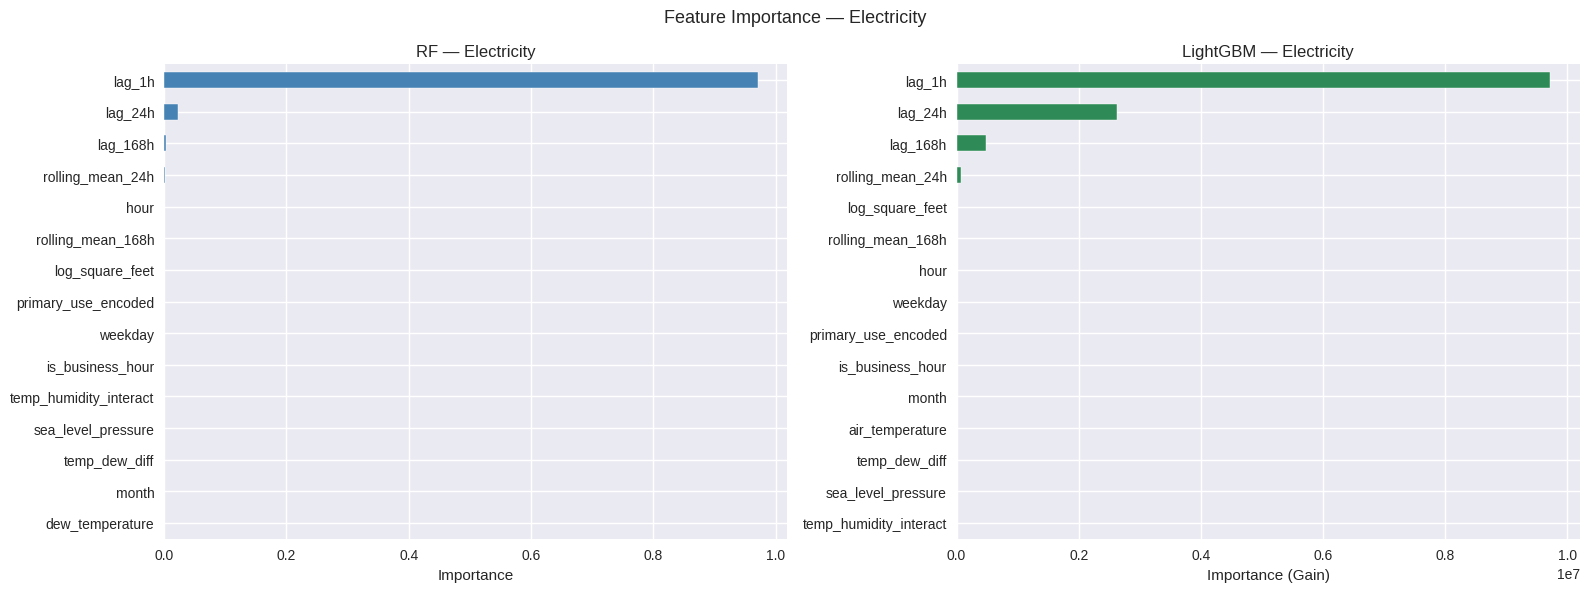

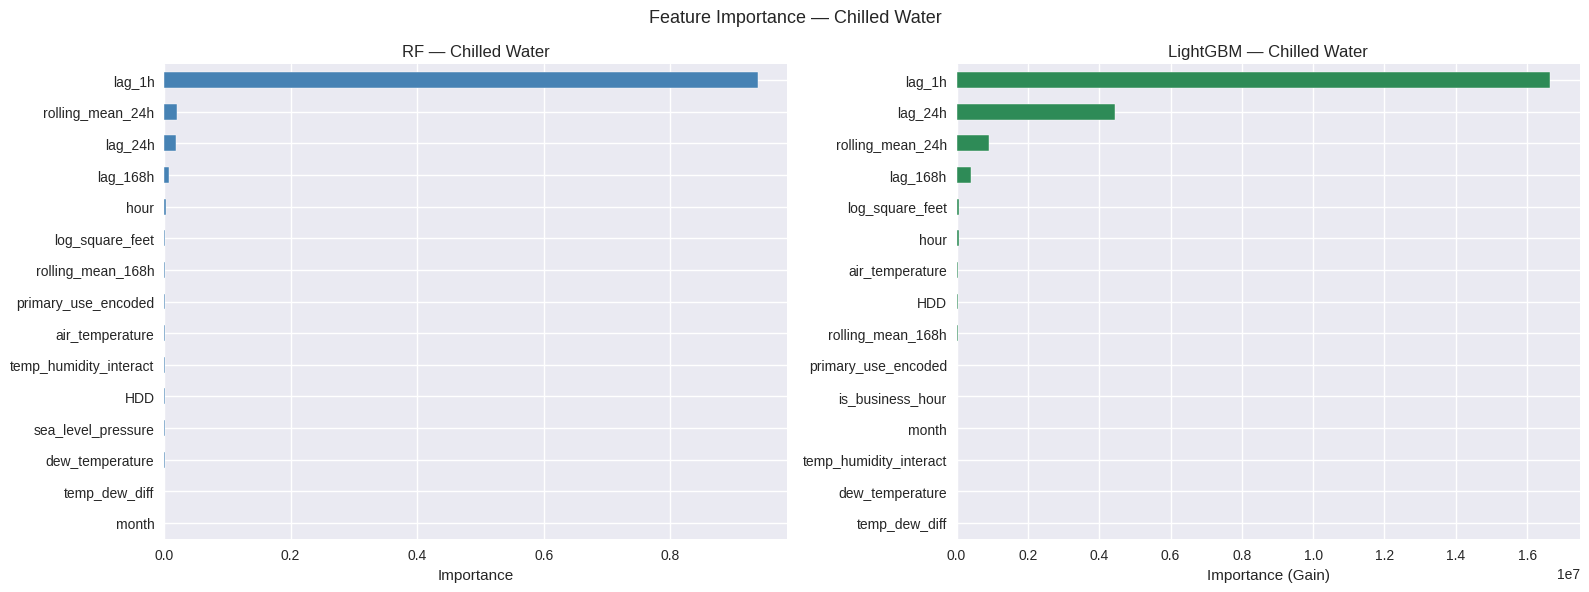

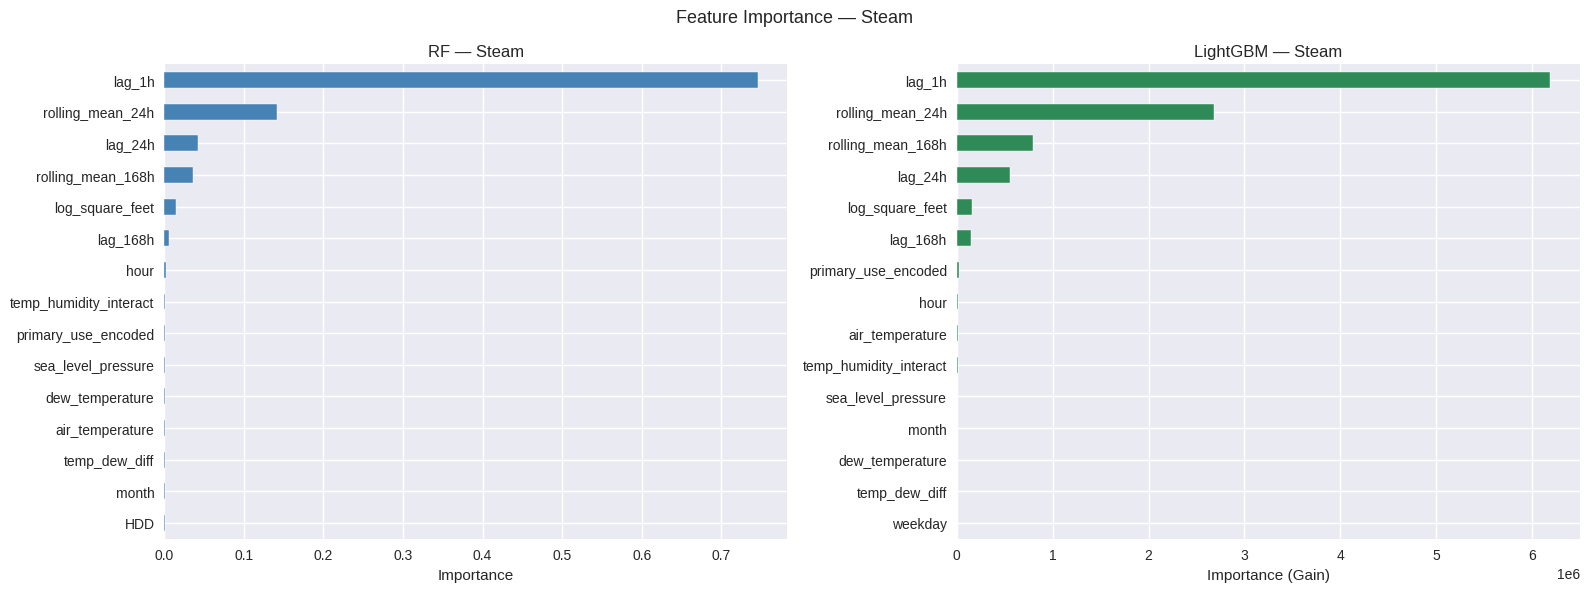

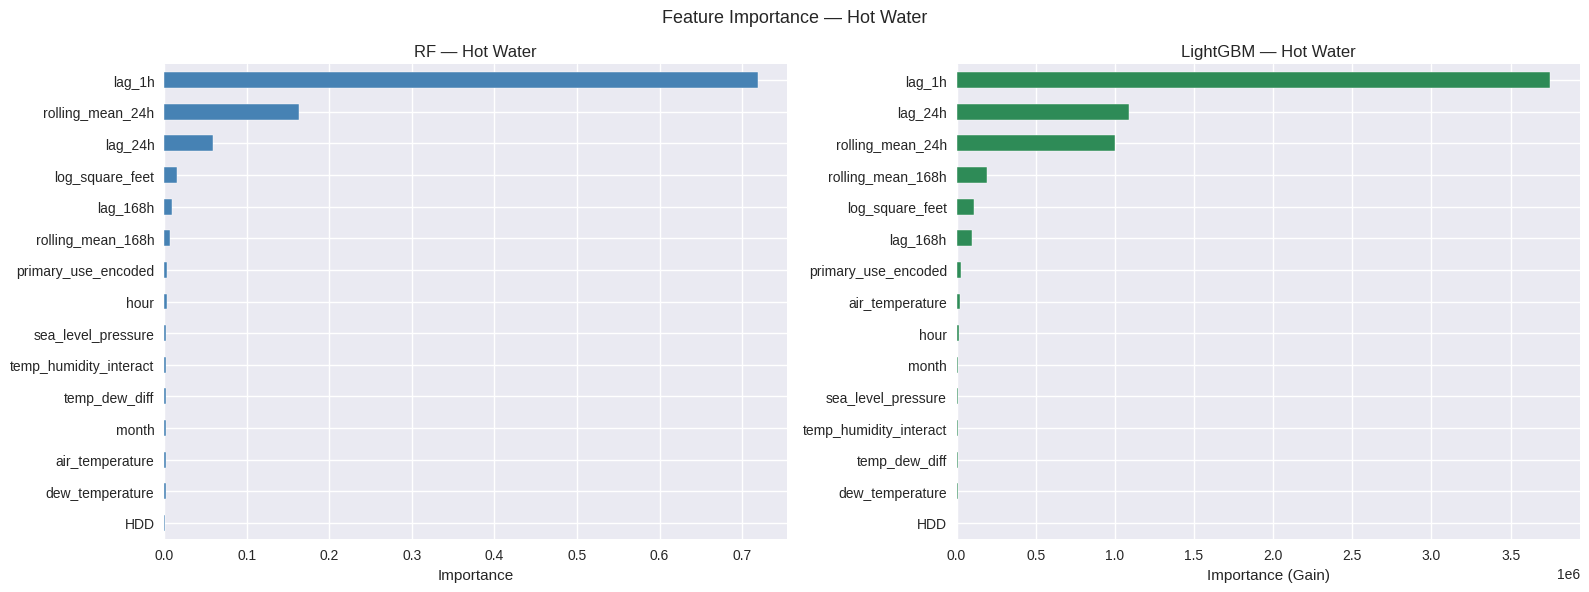

In [ ]:
for meter_name in rf_models.keys():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # RF importance
    rf_imp = pd.Series(
        rf_models[meter_name].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True).tail(15)
    rf_imp.plot(kind='barh', ax=axes[0],
                color='steelblue', edgecolor='white')
    axes[0].set_title(f'RF — {meter_name}')
    axes[0].set_xlabel('Importance')

    # LightGBM importance
    if meter_name in lgb_models:
        lgb_imp = pd.Series(
            lgb_models[meter_name].feature_importance(
                importance_type='gain'),
            index=X_train.columns
        ).sort_values(ascending=True).tail(15)
        lgb_imp.plot(kind='barh', ax=axes[1],
                     color='seagreen', edgecolor='white')
        axes[1].set_title(f'LightGBM — {meter_name}')
        axes[1].set_xlabel('Importance (Gain)')

    plt.suptitle(f'Feature Importance — {meter_name}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

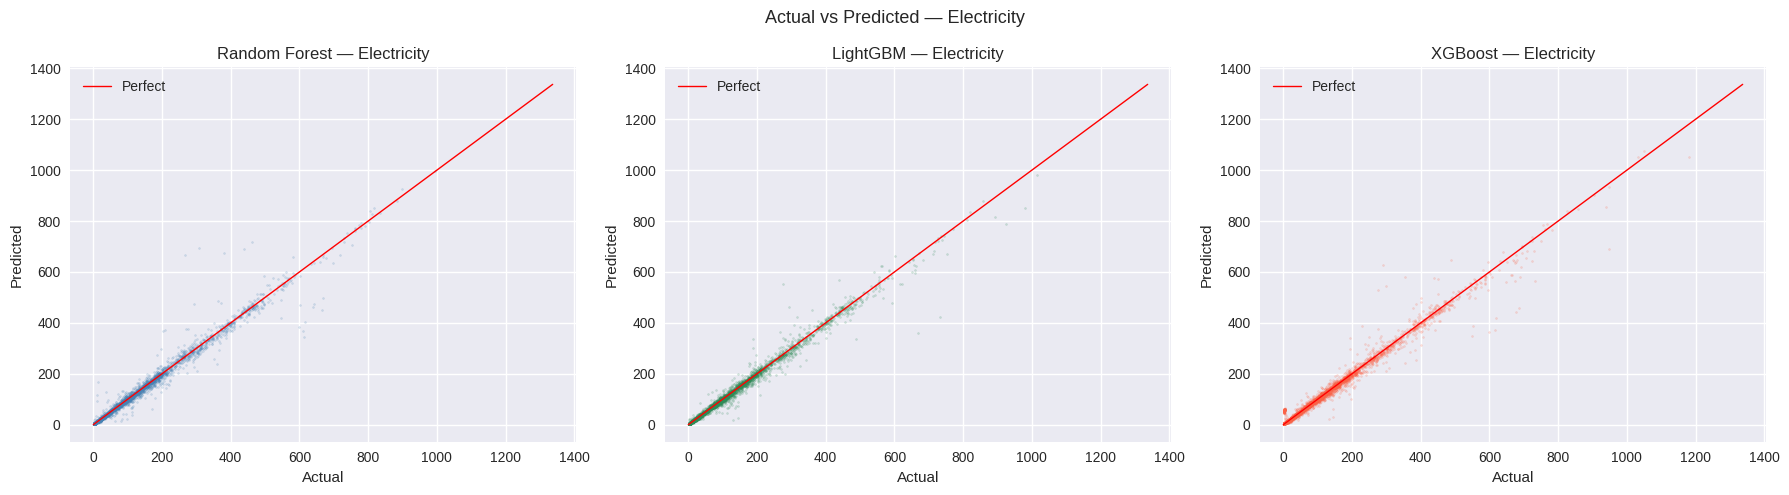

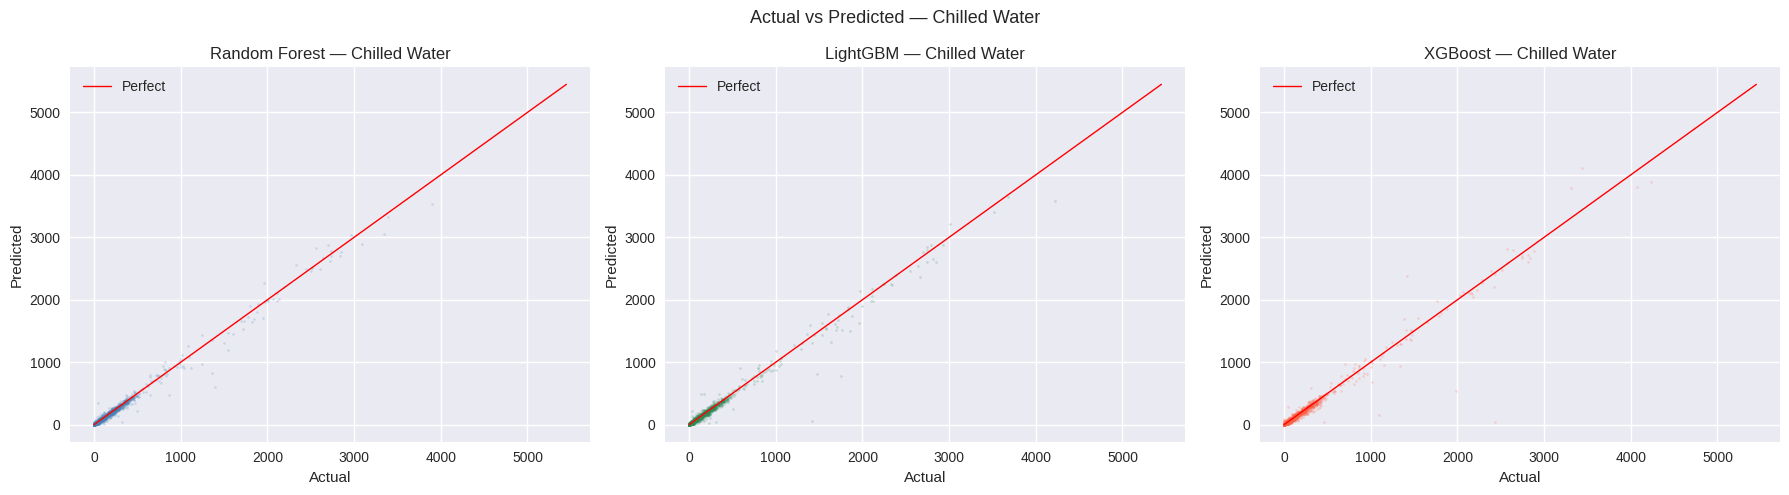

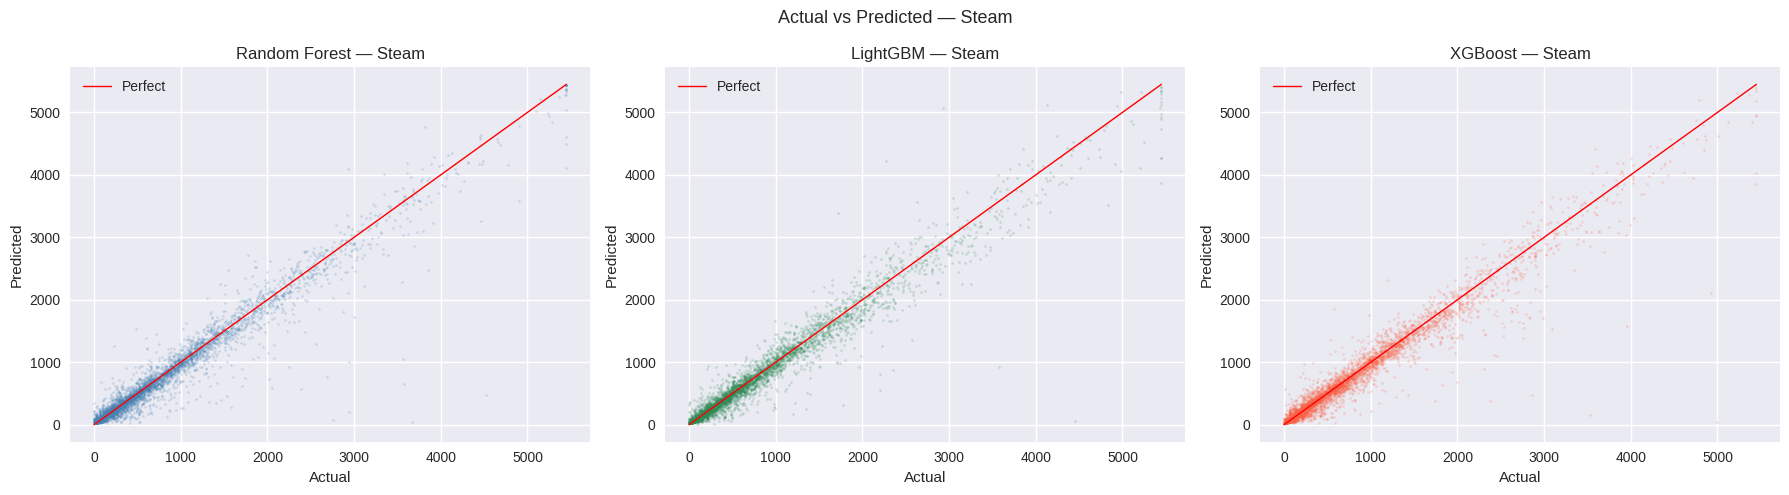

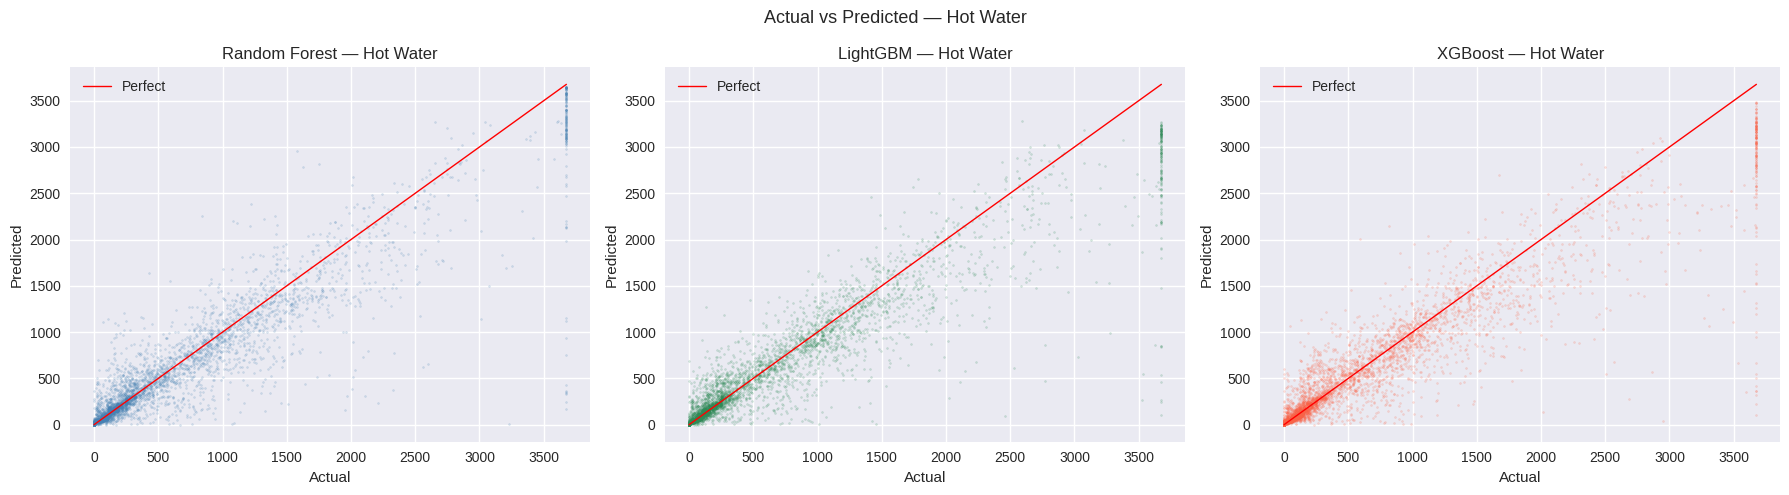

In [ ]:
for meter_id, meter_name in meter_map.items():
    mask_test = X_test['meter'] == meter_id
    X_te      = X_test[mask_test]
    y_te      = y_test[mask_test]

    if len(X_te) == 0:
        continue

    y_test_actual = np.expm1(y_te)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles  = ['Random Forest', 'LightGBM', 'XGBoost']
    colors  = ['steelblue', 'seagreen', 'tomato']
    preds   = [
        np.expm1(rf_models[meter_name].predict(X_te))
            if meter_name in rf_models else None,
        np.expm1(lgb_models[meter_name].predict(X_te))
            if meter_name in lgb_models else None,
        np.expm1(xgb_models[meter_name].predict(
            xgb.DMatrix(X_te)))
            if meter_name in xgb_models else None,
    ]

    for i, (title, color, y_pred) in enumerate(
            zip(titles, colors, preds)):
        if y_pred is None:
            continue
        sample_n   = min(5000, len(y_test_actual))
        sample_idx = np.random.choice(
            len(y_test_actual), sample_n, replace=False)
        axes[i].scatter(
            y_test_actual.values[sample_idx],
            y_pred[sample_idx],
            alpha=0.2, s=2, color=color)
        axes[i].plot(
            [0, y_test_actual.max()],
            [0, y_test_actual.max()],
            'r-', linewidth=1, label='Perfect')
        axes[i].set_title(f'{title} — {meter_name}')
        axes[i].set_xlabel('Actual')
        axes[i].set_ylabel('Predicted')
        axes[i].legend()

    plt.suptitle(f'Actual vs Predicted — {meter_name}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

FINAL ML MODEL COMPARISON — ALL METERS
        Meter         Model     RMSE      MAE     R²  RMSLE
  Electricity Random Forest  16.1935   6.2136 0.9840 0.1444
  Electricity      LightGBM  15.8818   6.3745 0.9846 0.1484
  Electricity       XGBoost  17.1788   7.1486 0.9820 0.3477
Chilled Water Random Forest  48.3539   9.9772 0.9634 0.2883
Chilled Water      LightGBM  47.9294  10.4395 0.9641 0.2914
Chilled Water       XGBoost  47.2138  10.4537 0.9651 0.3385
        Steam Random Forest 185.7366  94.8921 0.9552 0.4501
        Steam      LightGBM 187.8305  98.4489 0.9541 0.4219
        Steam       XGBoost 198.3644 101.0462 0.9489 0.4408
    Hot Water Random Forest 305.7083 142.5057 0.8708 0.6724
    Hot Water      LightGBM 319.8577 150.4892 0.8586 0.6535
    Hot Water       XGBoost 331.3823 156.4724 0.8482 0.6684


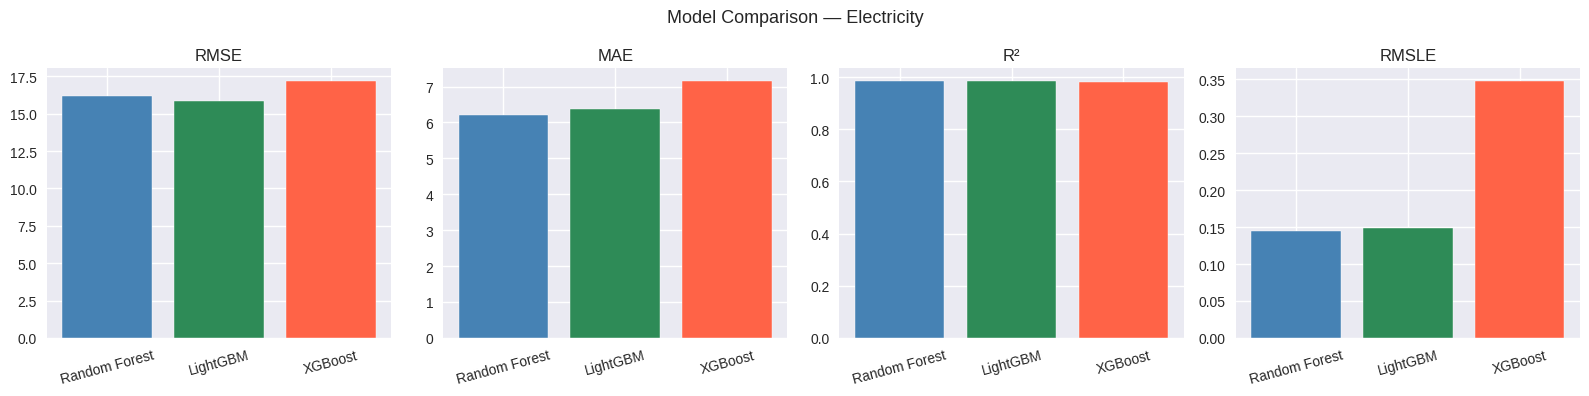

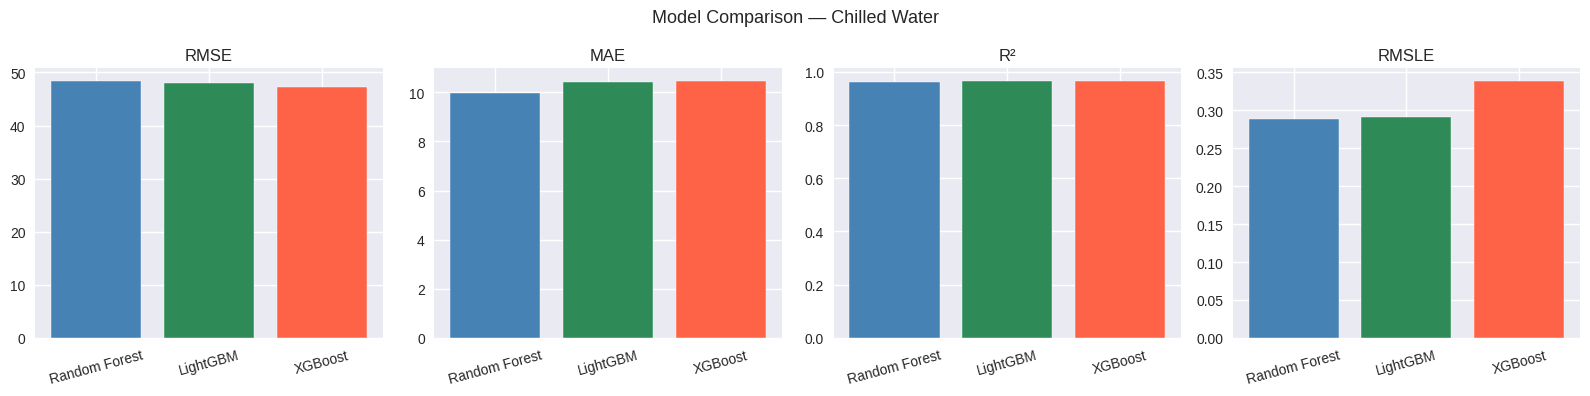

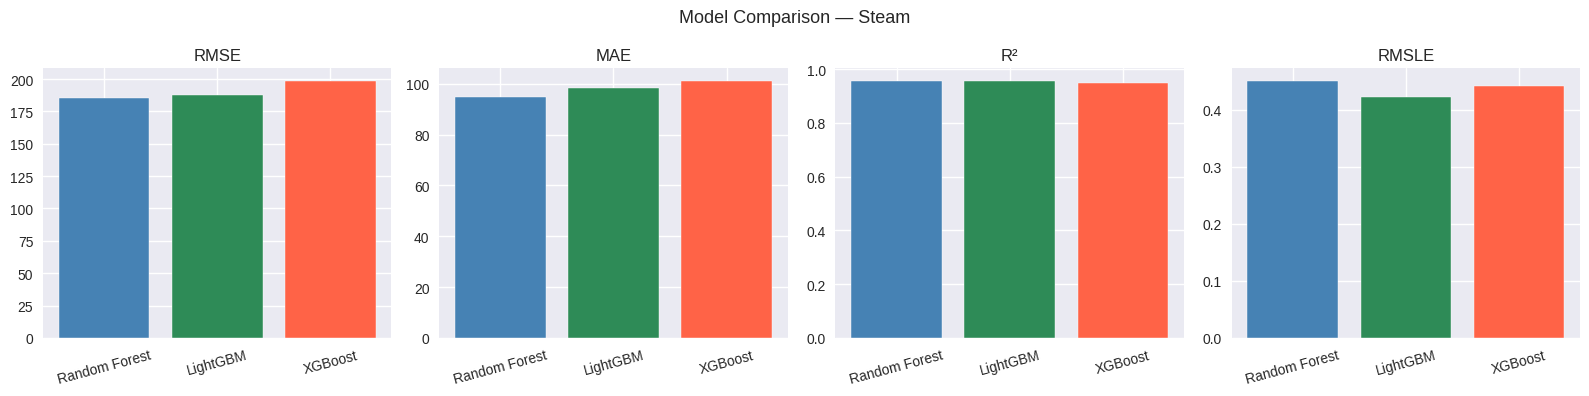

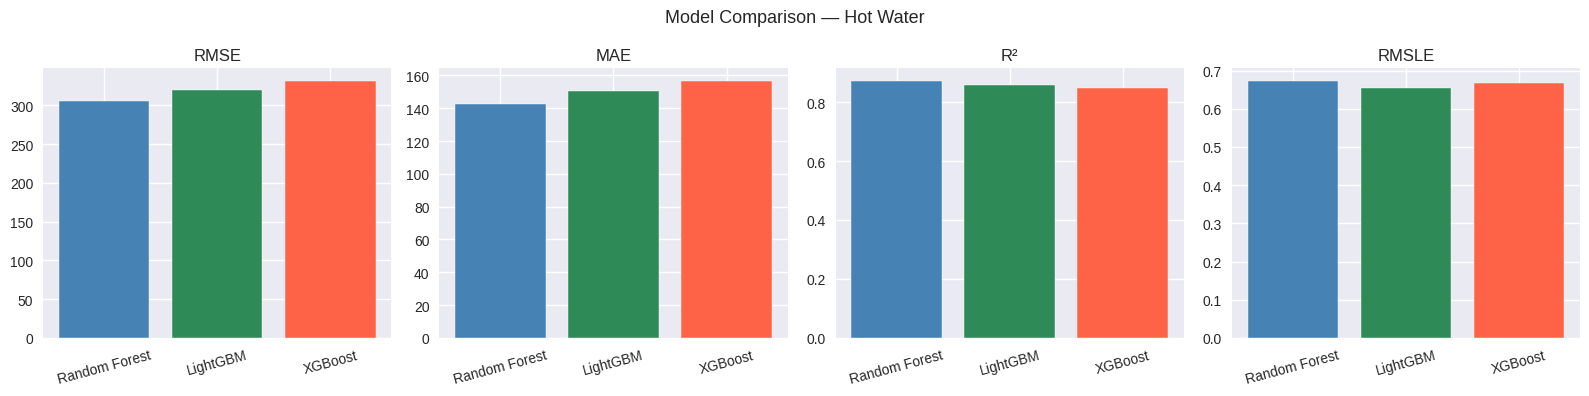

In [ ]:
summary = []
for meter_name in meter_map.values():
    for model_name, results_dict in [
        ('Random Forest', rf_results),
        ('LightGBM',      lgb_results),
        ('XGBoost',       xgb_results)
    ]:
        if meter_name in results_dict:
            s = results_dict[meter_name]
            summary.append({
                'Meter' : meter_name,
                'Model' : model_name,
                'RMSE'  : round(s[0], 4),
                'MAE'   : round(s[1], 4),
                'R²'    : round(s[2], 4),
                'RMSLE' : round(s[3], 4)
            })

summary_df = pd.DataFrame(summary)

print("=" * 70)
print("FINAL ML MODEL COMPARISON — ALL METERS")
print("=" * 70)
print(summary_df.to_string(index=False))

# Visual per meter
for meter_name in meter_map.values():
    mdf    = summary_df[summary_df['Meter'] == meter_name]
    if mdf.empty:
        continue
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    colors    = ['steelblue', 'seagreen', 'tomato']
    for i, metric in enumerate(['RMSE','MAE','R²','RMSLE']):
        axes[i].bar(mdf['Model'], mdf[metric],
                    color=colors, edgecolor='white')
        axes[i].set_title(metric)
        axes[i].tick_params(axis='x', rotation=15)
    plt.suptitle(f'Model Comparison — {meter_name}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()